# When Authorship Becomes Ambiguous: Decoding Public Perception and the Evolution of Cultural Value in the Age of AI


## Project Objective
As generative AI tools become increasingly integrated into creative production, the boundary between human and machine authorship is becoming more ambiguous. This project investigates how AI-assisted artworks are governed, interpreted, and valued across online communities and platform-facing signals.

The project is organized around a three-layer argument: AI art value is co-constructed through governance rules, audience discourse, and market signals, and these layers do not always align.

## Key Questions
1. How do online communities govern AI-generated art?
2. How do audiences interpret AI authorship, disclosure, and cultural value?
3. Which value frames dominate AI art discourse?
4. Do external price and engagement indicators show similarly strong differentiation across creator types?

## Data Sources
This analysis combines three datasets representing different layers of the AI art ecosystem:

- **Cornell Subreddit Rules Dataset** - captures governance policies of art communities toward AI-generated content.
- **Self-Collected Discourse Dataset (n = 200)** - manually coded comments used to analyze audience stance, cultural framing, disclosure, and interaction depth.
- **Kaggle AI Art Popularity Dataset** - an external dataset used as contextual market evidence for comparing price and engagement patterns across creator types.

## Analytical Workflow
1. Governance Layer  
2. Audience Discourse Layer  
3. Market Signal Layer  

## Final Output
A three-layer account of how AI art value is negotiated across governance, discourse, and market-facing signals, followed by interpretive recommendations for platforms and cultural institutions.

In [1]:
# ======================================
# Library Imports
# ======================================

import pandas as pd
import numpy as np
import re
import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

from pathlib import Path
from scipy.stats import chi2_contingency

# Visualization style
sns.set_style("whitegrid")

In [2]:
# ======================================
# Data Loading
# ======================================

BASE_DIR = Path(".")
data_dir = BASE_DIR / "Dataset"

df_rules = pd.read_csv(data_dir / "ai_rules_subreddit_set.csv")
df_discourse = pd.read_excel(data_dir / "Audience Discourse.xlsx", sheet_name="200 Records")
df_market = pd.read_csv(data_dir / "AI_Generated_Art_Popularity.csv")

# Backward-compatible aliases retained for older cells.
df = df_rules
df_Art = df_discourse
df_kaggle = df_market

print("Rules dataset:", df_rules.shape)
print("Discourse dataset:", df_discourse.shape)
print("Market dataset:", df_market.shape)

Rules dataset: (4251, 14)
Discourse dataset: (200, 10)
Market dataset: (5000, 10)


## Data Preparation Note

Each dataset represents a different analytical layer of the AI art ecosystem:

- **Governance Layer** - community policies regulating AI-generated content.
- **Discourse Layer** - audience interpretations and value framing in comment discussions.
- **Market Layer** - pricing and engagement signals across creator types.

The following sections analyze each layer sequentially before integrating findings into strategic recommendations.

## Layer 1: Governance Analysis

### Scope and Validation

This section examines how online art communities regulate AI-generated content.

Using the Cornell subreddit rules dataset, we analyze whether communities explicitly ban AI art, impose quality-based restrictions, require disclosure, or leave the policy ambiguous.

Before performing the governance analysis, we first verify the dataset structure and check for missing values to ensure the dataset is suitable for analysis.

In [3]:
# ======================================
# Dataset Validation
# ======================================

print("Missing values by column:")
print(df.isnull().sum())

print("\nDataset preview:")
display(df.head())

Missing values by column:
id                                                   0
name                                                 0
public_description                                 164
subscribers                                          0
rules                                                0
cleaned_rules                                        0
created_utc                                          0
topic_label                                          0
has_ai_rule_label                                    0
is_topical_question_and_answer_ca_label              0
is_learning_and_perspective_broadening_ca_label      0
is_social_support_ca_label                           0
is_content_generation_ca_label                       0
is_affiliation_with_an_entity_ca_label               0
dtype: int64

Dataset preview:


,id,name,public_description,subscribers,rules,cleaned_rules,created_utc,topic_label,has_ai_rule_label,is_topical_question_and_answer_ca_label,is_learning_and_perspective_broadening_ca_label,is_social_support_ca_label,is_content_generation_ca_label,is_affiliation_with_an_entity_ca_label
0,t5_2qh33,r/funny,Reddit's largest humor depository,65084935,"[{""kind"": ""link"", ""description"": ""Humor is sub...",- All posts must make an attempt at humor.(All...,1201242956,Humor,True,False,False,False,True,False
1,t5_2qh1i,r/AskReddit,r/AskReddit is the place to ask and answer tho...,49162704,"[{""kind"": ""link"", ""description"": ""* All questi...",- Rule 1 - Questions must be clear and direct ...,1201233135,Learning,True,True,True,False,False,False
2,t5_2qh13,r/worldnews,"A place for major news from around the world, ...",42569819,"[{""kind"": ""link"", ""description"": ""Articles abo...",- No US Internal News or Politics(US Internal ...,1201231119,News,True,False,True,False,False,False
3,t5_2qh1u,r/Music,Reddit’s #1 Music Community,35250321,"[{""kind"": ""link"", ""description"": ""Songs listed...",- No songs from the Hall of Fame(Rule 1: No so...,1201235432,Music,True,False,True,False,True,False
4,t5_2qh3s,r/movies,The goal of /r/Movies is to provide an inclusi...,33927588,"[{""kind"": ""all"", ""description"": ""Our [full lis...",- Do Familiarize Yourself With Our Rules.(I Do...,1201243950,Entertainment,True,True,True,False,False,False


### Data Validation Summary

The dataset contains subreddit-level information including rule descriptions, community size, topic labels, and AI-related governance indicators.

Most variables contain complete information. The only column with notable missing values is **public_description**, which is not directly required for the governance analysis because the analysis focuses primarily on rule text and policy labels.

Overall, the dataset appears structurally complete and suitable for further governance analysis.

### Module 1: Governance Stance Classification

To analyze how communities regulate AI-generated content, a rule-based classifier was constructed to identify governance approaches from subreddit rule text.

The classifier extracts several governance-related variables:

- `mentions_ai`: whether the rule text references AI or generative tools  
- `ai_ban`: explicit prohibition of AI-generated content  
- `ai_label`: disclosure or labeling requirement  
- `ai_quality`: quality-based restrictions targeting AI content  
- `ai_policy_mix`: combination of governance instruments  
- `ai_stance`: summarized governance stance  

These variables will be used in later sections to analyze governance patterns across communities.

In [4]:
# ============================================================
# Improved AI policy stance classifier for Cornell AI Rules data
# - Two-stage gating: (1) AI mention? (2) stance type
# - Vectorized (fast), auditable, low false positives
# - Multi-label outputs + a single "ai_stance" summary label
# - Use Cornell's has_ai_rule_label to filter scope
# ============================================================

# Ensure the rules column exists
RULE_COL = "cleaned_rules"   
HAS_AI_COL = "has_ai_rule_label"  
TOPIC_COL = "topic_label"    

# Safety: make a working text series
rules = df[RULE_COL].fillna("").astype(str)

# -----------------------------
# 1) Regex dictionaries (edit/extend as needed)
# -----------------------------
# Phase 1: "AI mention" gate, only if text is actually about AI or generated content
AI_MENTION_PATTERNS = [
    r"\bai\b",
    r"artificial\s+intelligence",
    r"\bgenerative\b",
    r"\bgenerated\b",
    r"\bsynthetic\b",
    r"machine[-\s]?generated",
    r"\baigc\b",
    r"deepfake(s)?",
    r"midjourney",
    r"stable\s+diffusion",
    r"dall[-\s]?e",
    r"chatgpt",
    r"prompt(s)?",
    r"genai",
]

# Phase 2: stance patterns (only applied where AI is mentioned)
BAN_PATTERNS = [
    r"\bno\s+ai\b",
    r"\bai\s+not\s+allowed\b",
    r"\bnot\s+allowed\s+(to\s+post\s+)?ai\b",
    r"\bdisallow(ed|s)?\b.*\b(ai|generated|synthetic)\b",
    r"\bforbid(den|s)?\b.*\b(ai|generated|synthetic)\b",
    r"\bprohibit(ed|s)?\b.*\b(ai|generated|synthetic)\b",
    r"\bban(ned|s)?\b.*\b(ai|generated|synthetic)\b",
    r"\bno\s+(generative|generated)\b",
    r"\bhuman[-\s]?only\b.*\b(art|content|work|posts?)\b",
    r"\bno\s+midjourney\b",
    r"\bno\s+stable\s+diffusion\b",
]

LABEL_PATTERNS = [
    r"\bmust\s+(label|tag|flair|disclose)\b",
    r"\brequire(d|s)?\b.*\b(label|tag|flair|disclos(e|ure))\b",
    r"\b(disclose|disclosure)\b.*\b(ai|generated|synthetic)\b",
    r"\b(mark|flag)\b.*\b(as\s+ai|ai[-\s]?generated)\b",
    r"\bai[-\s]?generated\b.*\b(tag|label|flair)\b",
    r"\bwatermark\b",
    r"\bsource\s+required\b",
    r"\bcredit\s+required\b",
]

QUALITY_PATTERNS = [
    r"\blow[-\s]?effort\b.*\b(ai|generated|synthetic)\b",
    r"\b(ai|generated|synthetic)\b.*\blow[-\s]?effort\b",
    r"\bspam\b.*\b(ai|generated|synthetic)\b",
    r"\b(ai|generated|synthetic)\b.*\bspam\b",
    r"\bno\s+prompt\s+dumps?\b",
    r"\bkarma\s+farm(ing)?\b",
    r"\brepost(s|ing)?\b.*\b(ai|generated|synthetic)\b",
    r"\bquality\b.*\b(ai|generated|synthetic)\b",
]

# Compile regex once for performance and readability
def to_non_capturing(pattern: str) -> str:
    return re.sub(r"\((?!\?)", "(?:", pattern)

AI_MENTION_PATTERNS_NC = [to_non_capturing(p) for p in AI_MENTION_PATTERNS]
BAN_PATTERNS_NC        = [to_non_capturing(p) for p in BAN_PATTERNS]
LABEL_PATTERNS_NC      = [to_non_capturing(p) for p in LABEL_PATTERNS]
QUALITY_PATTERNS_NC    = [to_non_capturing(p) for p in QUALITY_PATTERNS]

AI_MENTION_RE = re.compile("|".join(AI_MENTION_PATTERNS_NC), flags=re.IGNORECASE)
BAN_RE        = re.compile("|".join(BAN_PATTERNS_NC),        flags=re.IGNORECASE)
LABEL_RE      = re.compile("|".join(LABEL_PATTERNS_NC),      flags=re.IGNORECASE)
QUALITY_RE    = re.compile("|".join(QUALITY_PATTERNS_NC),    flags=re.IGNORECASE)

df["mentions_ai"] = rules.str.contains(AI_MENTION_RE, regex=True, na=False)

# -----------------------------
# 2) Decide analysis scope 
# -----------------------------
# If your file includes Cornell's has_ai_rule_label:
# - True  => subreddit has an AI rule (best scope for "stance") = True 
# - False => not an AI rule subreddit; do NOT call it "Open" = False 
if HAS_AI_COL in df.columns:
    scope_has_ai_rule = df[HAS_AI_COL].fillna(False).astype(bool)
else:
    scope_has_ai_rule = pd.Series([True] * len(df), index=df.index)  # fallback

# For stance analysis, you can choose:
# A) strict: only analyze those with Cornell label True = True
# B) broad: use text gate (AI mention) regardless of Cornell label
USE_STRICT_SCOPE = True  # set False if you want broader scanning 

if USE_STRICT_SCOPE and HAS_AI_COL in df.columns:
    in_scope = scope_has_ai_rule
else:
    # broad mode: in-scope if text mentions AI
    in_scope = rules.str.contains(AI_MENTION_RE)

# -----------------------------
# 3) Phase 2: stance detection (only where in_scope)
# -----------------------------
# Initialize flags
df["ai_ban"]      = False
df["ai_label"]    = False
df["ai_quality"]  = False

mask = in_scope & df["mentions_ai"]

df.loc[mask, "ai_ban"]     = rules[mask].str.contains(BAN_RE)
df.loc[mask, "ai_label"]   = rules[mask].str.contains(LABEL_RE)
df.loc[mask, "ai_quality"] = rules[mask].str.contains(QUALITY_RE)

# -----------------------------
# 4) Create a single stance label (auditable + conservative) 
# -----------------------------
def summarize_stance(row):
    """
    Conservative, hierarchy-based summary label.
    - If not in scope: Not Applicable
    - If AI mentioned but no stance patterns: Mentioned / Unclear
    - If ban present: Ban (even if other flags also present)
    - Else if label present: Regulated
        return "Quality Control"
    """
    if not row["in_scope"]:
        return "Not applicable (out of scope)"
    if not row["mentions_ai"]:
        # happens in strict scope mode when Cornell label True but text missing keywords
        return "AI rule labeled but AI terms not detected"
    if row["ai_ban"]:
        return "Ban / Prohibited"
    if row["ai_label"]:
        return "Regulated / Label Required"
    if row["ai_quality"]:
        return "Quality Control"
    return "AI mentioned / stance unclear"

df["in_scope"] = in_scope
df["ai_stance"] = df.apply(summarize_stance, axis=1)

# policy mix (multi-label summary)
def mix_tags(row):
    tags = []
    if row["ai_ban"]: tags.append("ban")
    if row["ai_label"]: tags.append("label")
    if row["ai_quality"]: tags.append("quality")
    return ",".join(tags) if tags else ""

df["ai_policy_mix"] = df.apply(mix_tags, axis=1)

# -----------------------------
# 5) Quick diagnostics 
# -----------------------------
print("Total communities:", len(df))
print("Communities in scope:", df["in_scope"].sum())

print("\nGovernance stance distribution:")
print(df.loc[df["in_scope"], "ai_stance"].value_counts())

# -----------------------------
# 6) Audit sample for manual validation
# -----------------------------
# Randomly sample subreddit rules from each governance stance to manually verify the classifier performance.

AUDIT_N_PER_CLASS = 25
RANDOM_SEED = 42

audit_frames = []

for stance, g in df.loc[df["in_scope"]].groupby("ai_stance"):
    sample_n = min(AUDIT_N_PER_CLASS, len(g))
    audit_frames.append(g.sample(sample_n, random_state=RANDOM_SEED))

audit_df = (
    pd.concat(audit_frames)
    .sort_values("ai_stance")
    .reset_index(drop=True)
)

# Columns useful for manual review
cols_to_show = [
    c for c in ["name", TOPIC_COL, "subscribers", "ai_stance", "ai_policy_mix", RULE_COL]
    if c in df.columns
]

# Export audit dataset
audit_df.to_csv("audit_sample_ai_stance.csv", index=False)

print("Audit sample exported: audit_sample_ai_stance.csv")
print("Rows exported:", len(audit_df))

Total communities: 4251
Communities in scope: 4251

Governance stance distribution:
ai_stance
Ban / Prohibited                             1834
AI mentioned / stance unclear                1667
Quality Control                               452
AI rule labeled but AI terms not detected     178
Regulated / Label Required                    120
Name: count, dtype: int64
Audit sample exported: audit_sample_ai_stance.csv
Rows exported: 125


### Model 2 - Governance Stance Distribution

Among communities that maintain AI-related rules, governance approaches vary substantially.

A large portion of communities adopt **strict prohibitions**, explicitly banning AI-generated content from submissions. This suggests that many moderators view generative outputs as incompatible with their community norms or quality standards.

Another large share of communities **acknowledge AI but do not specify a clear stance**. These rules often mention AI without explicitly banning it or defining moderation requirements, which may reflect transitional governance as communities adapt to rapidly evolving generative technologies.

A smaller set of communities allow AI content under **regulatory conditions**, such as labeling or disclosure requirements, while others manage AI indirectly through **quality control policies** that target spam or low-effort submissions.

Overall, the governance landscape appears fragmented, with communities experimenting with different strategies to manage the integration of AI-generated content.

C:\Users\User\AppData\Local\Temp\ipykernel_13160\393488452.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


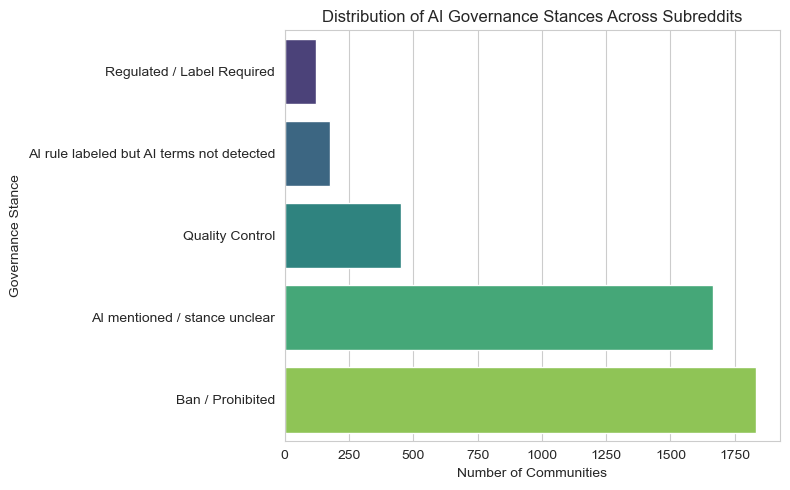

In [5]:
# Clean stance labels for visualization
stance_label_map = {
    "Ban / Prohibited": "Ban / Prohibited",
    "Regulated / Label Required": "Regulated / Label Required",
    "Quality Control": "Quality Control",
    "AI mentioned / stance unclear": "AI mentioned / stance unclear",
    "AI rule labeled but AI terms not detected": "AI rule labeled but AI terms not detected"
}

df["ai_stance_clean"] = df["ai_stance"].replace(stance_label_map)


# Governance stance distribution chart

stance_counts = (
    df.loc[df["in_scope"], "ai_stance_clean"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=stance_counts.values,
    y=stance_counts.index,
    palette="viridis"
)

plt.title("Distribution of AI Governance Stances Across Subreddits")
plt.xlabel("Number of Communities")
plt.ylabel("Governance Stance")

plt.tight_layout()
plt.show()

### Module 3 - Governance Variation by Community Topic

To examine whether AI governance differs across cultural contexts, governance stance is compared across subreddit topic categories.

Because community topics vary greatly in size, the analysis focuses on **within-topic percentages** rather than raw counts. This allows a more comparable view of whether certain domains are more likely to prohibit AI, regulate it through disclosure, or rely on quality-based moderation.

In [6]:
# ======================================
# Module 3: Governance by Topic
# ======================================

df_scope = df[df["in_scope"].fillna(False)].copy()

df_scope["topic_label"] = df_scope["topic_label"].fillna("Unknown").astype(str)
df_scope["ai_stance_clean"] = df_scope["ai_stance_clean"].fillna("Unknown").astype(str)

print("Scoped dataset shape:", df_scope.shape)

Scoped dataset shape: (4251, 22)


In [7]:
topic_stance_counts = pd.crosstab(
    df_scope["topic_label"],
    df_scope["ai_stance_clean"]
)

display(topic_stance_counts)

ai_stance_clean,AI mentioned / stance unclear,AI rule labeled but AI terms not detected,Ban / Prohibited,Quality Control,Regulated / Label Required
topic_label,,,,,
Animals,16,2,37,12,3
Art,302,14,176,35,25
Business and Organizations,18,3,12,8,1
Celebrity,207,58,474,33,7
Culture,2,1,8,5,2
Entertainment,368,27,452,98,31
Fashion,12,1,14,1,1
Food,9,2,15,5,2
Games,88,4,69,31,7


In [8]:
topic_stance_pct = pd.crosstab(
    df_scope["topic_label"],
    df_scope["ai_stance_clean"],
    normalize="index"
) * 100

topic_stance_pct = topic_stance_pct.round(1)

display(topic_stance_pct)

ai_stance_clean,AI mentioned / stance unclear,AI rule labeled but AI terms not detected,Ban / Prohibited,Quality Control,Regulated / Label Required
topic_label,,,,,
Animals,22.9,2.9,52.9,17.1,4.3
Art,54.7,2.5,31.9,6.3,4.5
Business and Organizations,42.9,7.1,28.6,19.0,2.4
Celebrity,26.6,7.4,60.8,4.2,0.9
Culture,11.1,5.6,44.4,27.8,11.1
Entertainment,37.7,2.8,46.3,10.0,3.2
Fashion,41.4,3.4,48.3,3.4,3.4
Food,27.3,6.1,45.5,15.2,6.1
Games,44.2,2.0,34.7,15.6,3.5


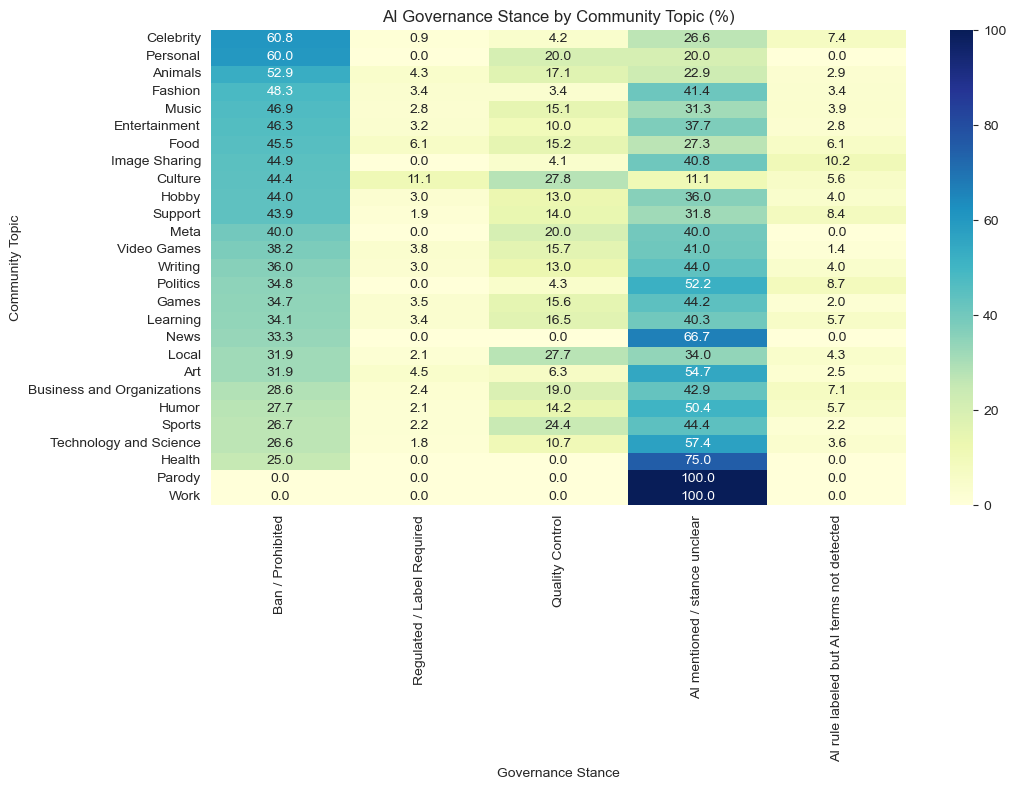

In [9]:
stance_order = [
    "Ban / Prohibited",
    "Regulated / Label Required",
    "Quality Control",
    "AI mentioned / stance unclear",
    "AI rule labeled but AI terms not detected"
]

topic_stance_pct_sorted = topic_stance_pct[stance_order].sort_values(
    by="Ban / Prohibited",
    ascending=False
)

plt.figure(figsize=(11, 8))

sns.heatmap(
    topic_stance_pct_sorted,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("AI Governance Stance by Community Topic (%)")
plt.xlabel("Governance Stance")
plt.ylabel("Community Topic")

plt.tight_layout()
plt.show()

#### Topic-Level Governance Patterns

Governance approaches vary meaningfully across community topics.

Some topics show a stronger tendency toward **direct prohibition**, suggesting lower tolerance for AI-generated content within those cultural spaces. Other topics rely more heavily on **quality control** or leave the stance **unclear**, which may indicate a more transitional or flexible governance approach.

These differences suggest that AI governance is not uniform across communities. Instead, it appears to reflect the underlying norms, expectations, and value systems of different cultural domains.

### Module 4 - Policy Instrument Overlap

Beyond overall governance stance, communities may combine multiple policy instruments when regulating AI-generated content. For example, a subreddit may both prohibit AI content and describe it as low-effort or spam, indicating a layered moderation approach.

This section examines the most common combinations of policy instruments identified by the classifier.

In [10]:
# ======================================
# Module 4: Policy Instrument Overlap
# ======================================

policy_mix_counts = (
    df.loc[df["in_scope"], "ai_policy_mix"]
    .replace("", "No explicit pattern")
    .value_counts()
    .rename_axis("Policy Mix")
    .reset_index(name="Count")
)

policy_mix_counts["Percentage"] = (
    policy_mix_counts["Count"] / policy_mix_counts["Count"].sum() * 100
).round(1)

display(policy_mix_counts)

,Policy Mix,Count,Percentage
0,No explicit pattern,1845,43.4
1,ban,1216,28.6
2,"ban,quality",572,13.5
3,quality,452,10.6
4,label,91,2.1
5,"ban,label",38,0.9
6,"label,quality",29,0.7
7,"ban,label,quality",8,0.2


C:\Users\User\AppData\Local\Temp\ipykernel_13160\1769155088.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


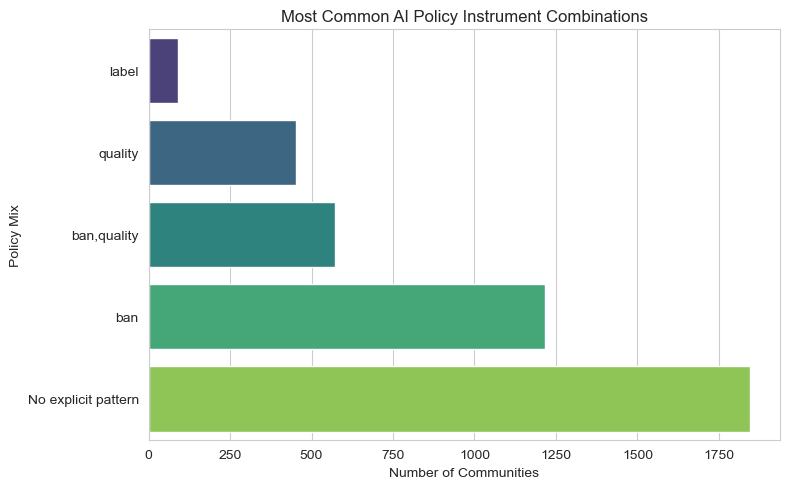

In [11]:
top_mix = policy_mix_counts.head(5).sort_values("Count", ascending=True)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=top_mix,
    x="Count",
    y="Policy Mix",
    palette="viridis"
)

plt.title("Most Common AI Policy Instrument Combinations")
plt.xlabel("Number of Communities")
plt.ylabel("Policy Mix")

plt.tight_layout()
plt.show()

#### Policy Instrument Overlap

Beyond overall governance stance, communities often combine multiple policy instruments when regulating AI-generated content.

The results show that a large share of communities mention AI without specifying a clear governance policy. This suggests that many communities are still in a transitional phase, acknowledging the presence of generative AI while continuing to negotiate how it should be integrated into community norms.

Among communities with explicit policies, outright prohibition is the most common governance approach. In many cases, bans are accompanied by quality-based moderation language, where AI-generated content is framed as low-effort or spam.

By contrast, transparency-based governance, such as requiring AI-generated content to be labeled, is relatively rare. This indicates that most communities currently respond to AI-generated content through exclusion or quality moderation rather than structured disclosure frameworks.

In [12]:
overlap_cases = df.loc[
    df["in_scope"] & df["ai_policy_mix"].str.contains(",", na=False),
    "ai_policy_mix"
].value_counts()

print("Policy mixes involving multiple governance instruments:")
print(overlap_cases)

Policy mixes involving multiple governance instruments:
ai_policy_mix
ban,quality          572
ban,label             38
label,quality         29
ban,label,quality      8
Name: count, dtype: int64


In [13]:
total_scope = df["in_scope"].sum()

overlap_total = overlap_cases.sum()

print("Communities using multiple governance instruments:", overlap_total)
print("Percentage:", round(overlap_total / total_scope * 100, 2), "%")

Communities using multiple governance instruments: 647
Percentage: 15.22 %


#### Layered Governance: Do Communities Combine Policy Instruments?

While most communities rely on a single governance instrument, a meaningful minority adopt **layered governance approaches** when regulating AI-generated content.

Across the dataset, approximately **15% of communities combine multiple policy instruments** rather than relying on a single rule. These layered policies typically appear when moderators seek to reinforce a governance stance through multiple moderation logics.

The most common combination is **ban + quality control**, which accounts for the vast majority of multi-instrument cases. In these communities, AI-generated content is not only prohibited but also framed as **low-effort, spam-like, or harmful to content quality**. This suggests that AI governance is often justified through **quality protection norms**, rather than framed purely as a technological restriction.

By contrast, combinations involving **disclosure or labeling requirements** are relatively rare. Policies that require AI-generated content to be explicitly labeled appear infrequently, both as standalone governance mechanisms and as part of policy mixes.

Overall, these results suggest that most communities respond to AI-generated content through **simple governance structures**, typically relying on a single moderation rule. When layered governance does occur, it most often reinforces prohibition through quality-based moderation rather than transparency-based regulation.

## Audience Discourse Layer

## Layer 2: Audience Discourse Analysis

After examining how online communities govern AI-generated content, the next step is to understand how audiences themselves interpret and evaluate AI-generated artworks.

The self-collected comment dataset (n = 200) was analyzed to examine audience discourse around AI-generated art. This layer focuses on four connected dimensions of audience response: **cultural framing**, **stance**, **interaction depth**, and **disclosure as a discourse variable**.

The analysis proceeds through several stages:

1. **Frame distribution**  
   Identifies which cultural value frames dominate audience discussions.

2. **Interaction depth by frame**  
   Examines which frames are more likely to generate deeper argumentative engagement.

3. **Stance distribution**  
   Summarizes overall audience attitudes toward AI-generated art.

4. **Frame and stance relationship**  
   Shows how specific interpretive frames are associated with positive, negative, or mixed responses.

5. **Disclosure comparison**  
   Evaluates whether explicit AI authorship disclosure shifts audience reactions, including both stance and interpretive framing.

Because the number of non-disclosed cases is relatively small, disclosure-based comparisons are interpreted as exploratory rather than causal.

To understand how audiences interpret AI-generated art, a discourse dataset of manually coded comments was analyzed.

Two features were constructed to capture the depth of audience engagement:

- **Word count**, representing comment length
- **Argument markers**, indicating whether the comment contains reasoning or evaluative language

Comments containing both longer text and argumentative language were classified as **high interaction depth**, representing deeper engagement with the artwork and its authorship.

--- Overall interaction depth distribution ---
interaction_depth
Low     89.0
High    11.0
Name: proportion, dtype: float64

--- Distribution of interaction depth by cultural frame (%) ---
interaction_depth                    High    Low
frame_manual                                    
Aesthetic Evaluation                 3.33  96.67
Authorship & Scarcity Value          8.93  91.07
Emotional Labor & Storytelling      15.00  85.00
Ethical & IP Governance             13.33  86.67
Human Authenticity & Resonance      18.42  81.58
Technical Sophistication & Novelty   7.69  92.31


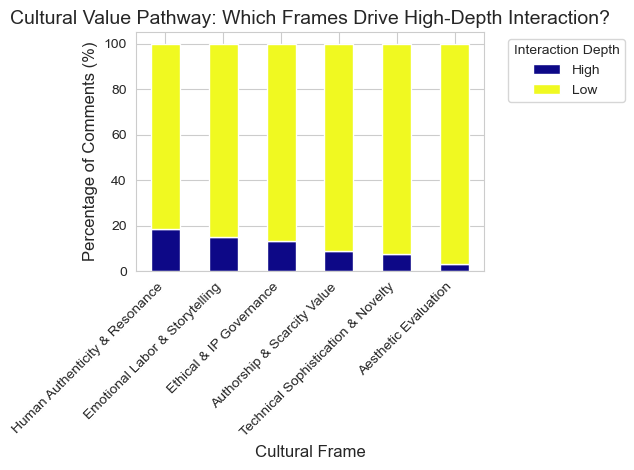


--- AI Disclosure vs Interaction Depth (%) ---
interaction_depth   High     Low
ai_disclosed                    
No                  0.00  100.00
Yes                12.64   87.36

--- Chi-square test for disclosure vs interaction depth ---
Chi-square value: 2.515
p-value: 0.11276319080496375


In [14]:
# ==========================================
# 1. Feature Engineering for AI art VS Human Art dataset
# ==========================================
# Count comment length
df_discourse['word_count'] = df_discourse['comment_text'].apply(lambda x: len(str(x).split()))

# Argument markers indicating reasoning
arg_keywords = [
    'because','therefore','according','should','must',
    'real','human','original','process'
]

pattern = re.compile(r'\b(' + '|'.join(arg_keywords) + r')\b', flags=re.IGNORECASE)

df_discourse['argument_marker'] = df_discourse['comment_text'].apply(
    lambda x: 'Yes' if pattern.search(str(x)) else 'No'
)

# Generate interaction depth variable
df_discourse['interaction_depth'] = df_discourse.apply(
    lambda row: 'High'
    if (row['word_count'] > 12 and row['argument_marker'] == 'Yes')
    else 'Low',
    axis=1
)

print("--- Overall interaction depth distribution ---")
print(df_discourse['interaction_depth'].value_counts(normalize=True).round(2) * 100)


# ==========================================
# 2. Cultural Frame vs Interaction Depth
# ==========================================

frame_depth = pd.crosstab(
    df_discourse['frame_manual'],
    df_discourse['interaction_depth'],
    normalize='index'
) * 100

print("\n--- Distribution of interaction depth by cultural frame (%) ---")
print(frame_depth.round(2))

# Sort by high-depth interaction
frame_depth_sorted = frame_depth.sort_values(by='High', ascending=False)

# Visualization
frame_depth_sorted.plot(
    kind='bar',
    stacked=True,
    colormap='plasma'
)

plt.title("Cultural Value Pathway: Which Frames Drive High-Depth Interaction?", fontsize=14)
plt.xlabel("Cultural Frame", fontsize=12)
plt.ylabel("Percentage of Comments (%)", fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.legend(title='Interaction Depth', bbox_to_anchor=(1.05,1), loc='upper left')

plt.tight_layout()
plt.show()


# ==========================================
# 3. AI Disclosure vs Interaction Depth
# ==========================================

blind_analysis = pd.crosstab(
    df_discourse['ai_disclosed'],
    df_discourse['interaction_depth'],
    normalize='index'
) * 100

print("\n--- AI Disclosure vs Interaction Depth (%) ---")
print(blind_analysis.round(2))


# ==========================================
# 4. Statistical Significance Test
# ==========================================

chi_table = pd.crosstab(
    df_discourse['ai_disclosed'],
    df_discourse['interaction_depth']
)

chi2, p, dof, expected = chi2_contingency(chi_table)

print("\n--- Chi-square test for disclosure vs interaction depth ---")
print("Chi-square value:", round(chi2,3))
print("p-value:", p)

### Interaction Depth in Audience Discourse

Most audience comments remain relatively short and reactive. Only a small proportion of comments contain argumentative language or extended reasoning, suggesting that deep engagement with the topic remains limited within the observed discussions.

However, interaction depth varies across cultural frames. In this sample, **Human Authenticity & Resonance**, **Emotional Labor & Storytelling**, and **Ethical & IP Governance** show the highest shares of high-depth comments, while **Aesthetic Evaluation** remains comparatively low. This suggests that debates around AI-generated art are often tied to questions of **human meaning, legitimacy, and governance**, rather than visual judgment alone.

When comparing disclosed versus non-disclosed cases, comments in the disclosed condition show a higher share of argumentative engagement within this sample. However, the difference is not statistically significant (Chi-square test p > 0.05), so the effect of disclosure on interaction depth cannot be confirmed within this dataset.

### Disclosure and Argumentative Engagement

Due to the relatively small number of non-disclosed cases, this comparison should be interpreted as exploratory.

A comparison between disclosed and non-disclosed AI artworks suggests that deeper argumentative discussion appears more frequently in disclosed cases within this sample. When AI involvement is not disclosed, comments are fewer in number and remain concentrated in a narrower set of frames.

One possible interpretation is that authorship disclosure may invite broader cultural debate around authenticity, legitimacy, and creative labor. However, because the number of non-disclosed cases is still relatively small (n = 26), and the statistical test does not indicate a significant difference, these observations should be interpreted as **descriptive and exploratory rather than causal conclusions**.


### SQL Cross-Checks: Cultural Frames and Interaction Patterns

To complement the Python-based analysis, SQL queries were used to explore how different cultural frames appear within the discourse dataset and how they relate to interaction depth.

SQL aggregation is particularly useful for quickly summarizing discourse patterns and comparing engagement levels across interpretive frames.

The following queries demonstrate how audience responses distribute across value frames, and whether certain frames are more likely to produce deeper argumentative discussions.

### Sanity Checks

To ensure analytical consistency, several validation checks were performed across the Python and SQL implementations.

1. **Dataset size verification**  
   The number of observations (n = 200) remains consistent across Python and SQL queries.

2. **Frame distribution validation**  
   Aggregated counts derived from SQL queries match the original manual coding results.

3. **Interaction depth classification check**  
   The distribution of high and low interaction depth was verified against raw comment counts.

These checks confirm that the analytical pipeline produces consistent results across different computation layers.

In [15]:
# ==========================================
# Sanity Checks
# ==========================================

# 1 Dataset size check (Python vs SQL)
print("Python row count:", df_discourse.shape[0])

display(
    duckdb.query("""
    SELECT COUNT(*) AS sql_row_count
    FROM df_discourse
    """).to_df()
)


# 2 Frame distribution validation (manual coding consistency)
print("\nFrame distribution (Python):")
display(df_discourse["frame_manual"].value_counts())

print("\nFrame distribution (SQL):")
display(
    duckdb.query("""
    SELECT frame_manual, COUNT(*) AS comment_count
    FROM df_discourse
    GROUP BY frame_manual
    ORDER BY comment_count DESC
    """).to_df()
)


# 3 Interaction depth validation
print("\nInteraction depth distribution:")
display(df_discourse["interaction_depth"].value_counts())

print("\nFrame x interaction depth:")
display(
    pd.crosstab(
        df_discourse["frame_manual"],
        df_discourse["interaction_depth"]
    )
)

Python row count: 200


,sql_row_count
0,200



Frame distribution (Python):


frame_manual
Authorship & Scarcity Value           56
Human Authenticity & Resonance        38
Aesthetic Evaluation                  30
Ethical & IP Governance               30
Technical Sophistication & Novelty    26
Emotional Labor & Storytelling        20
Name: count, dtype: int64


Frame distribution (SQL):


,frame_manual,comment_count
0,Authorship & Scarcity Value,56
1,Human Authenticity & Resonance,38
2,Aesthetic Evaluation,30
3,Ethical & IP Governance,30
4,Technical Sophistication & Novelty,26
5,Emotional Labor & Storytelling,20



Interaction depth distribution:


interaction_depth
Low     178
High     22
Name: count, dtype: int64


Frame x interaction depth:


interaction_depth,High,Low
frame_manual,,
Aesthetic Evaluation,1,29
Authorship & Scarcity Value,5,51
Emotional Labor & Storytelling,3,17
Ethical & IP Governance,4,26
Human Authenticity & Resonance,7,31
Technical Sophistication & Novelty,2,24


### 1. Distribution of Cultural Frames

This query examines how frequently each cultural frame appears within the discourse dataset. Understanding the baseline distribution helps identify which value perspectives dominate the discussion around AI-generated art.

In [16]:
sql_frame_distribution = """
SELECT
    frame_manual,
    COUNT(*) AS comment_count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentage
FROM df_discourse
GROUP BY frame_manual
ORDER BY comment_count DESC
"""

frame_distribution = duckdb.query(sql_frame_distribution).to_df()
print(frame_distribution)

                         frame_manual  comment_count  percentage
0         Authorship & Scarcity Value             56        28.0
1      Human Authenticity & Resonance             38        19.0
2                Aesthetic Evaluation             30        15.0
3             Ethical & IP Governance             30        15.0
4  Technical Sophistication & Novelty             26        13.0
5      Emotional Labor & Storytelling             20        10.0


### 2. Interaction Depth by Cultural Frame

To examine which cultural frames generate deeper discussions, comments are grouped by both discourse frame and interaction depth. This allows us to observe whether certain frames are more likely to produce argumentative or extended responses.

In [17]:
sql_interaction_depth = """
SELECT
    frame_manual,
    interaction_depth,
    COUNT(*) AS comment_count
FROM df_discourse
GROUP BY frame_manual, interaction_depth
ORDER BY frame_manual, interaction_depth
"""

interaction_depth_sql = duckdb.query(sql_interaction_depth).to_df()
print(interaction_depth_sql)

                          frame_manual interaction_depth  comment_count
0                 Aesthetic Evaluation              High              1
1                 Aesthetic Evaluation               Low             29
2          Authorship & Scarcity Value              High              5
3          Authorship & Scarcity Value               Low             51
4       Emotional Labor & Storytelling              High              3
5       Emotional Labor & Storytelling               Low             17
6              Ethical & IP Governance              High              4
7              Ethical & IP Governance               Low             26
8       Human Authenticity & Resonance              High              7
9       Human Authenticity & Resonance               Low             31
10  Technical Sophistication & Novelty              High              2
11  Technical Sophistication & Novelty               Low             24


### 3. Governance Context of Art Communities

To contextualize audience discourse, the governance environment of art-related communities was examined using the Cornell subreddit rules dataset.

This query summarizes how art-focused subreddits regulate AI-generated content, including the prevalence of bans, labeling requirements, and quality-based moderation policies.

In [18]:
sql_gov_summary = """
WITH gov_topic AS (
    SELECT
        topic_label,
        COUNT(*) AS n_subreddits,
        AVG(CASE WHEN ai_ban THEN 1 ELSE 0 END) AS ban_rate,
        AVG(CASE WHEN ai_label THEN 1 ELSE 0 END) AS label_rate,
        AVG(CASE WHEN ai_quality THEN 1 ELSE 0 END) AS quality_rate
    FROM df_scope
    WHERE in_scope = TRUE
    GROUP BY topic_label
)

SELECT *
FROM gov_topic
WHERE topic_label = 'Art'
"""

gov_art = duckdb.query(sql_gov_summary).to_df()
print(gov_art)

  topic_label  n_subreddits  ban_rate  label_rate  quality_rate
0         Art           552  0.318841    0.061594      0.096014


### Disclosure as a Discourse Variable

### 1. Distribution of Cultural Frames

This query summarizes how frequently each cultural frame appears in the discourse dataset. It provides a baseline view of which value perspectives dominate audience discussions around AI-generated art.

In [19]:
sql_frame_distribution = """
SELECT
    frame_manual,
    COUNT(*) AS comment_count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentage
FROM df_discourse
GROUP BY frame_manual
ORDER BY comment_count DESC
"""

frame_distribution_df = duckdb.query(sql_frame_distribution).to_df()
print(frame_distribution_df)

                         frame_manual  comment_count  percentage
0         Authorship & Scarcity Value             56        28.0
1      Human Authenticity & Resonance             38        19.0
2                Aesthetic Evaluation             30        15.0
3             Ethical & IP Governance             30        15.0
4  Technical Sophistication & Novelty             26        13.0
5      Emotional Labor & Storytelling             20        10.0


### 2. Interaction Depth by Cultural Frame

This query examines whether certain cultural frames are more likely to generate deeper discussions. Interaction depth is operationalized as a binary variable indicating whether a comment contains extended reasoning or argumentative language.

In [20]:
query = """
WITH frame_interaction_summary AS (
    SELECT 
        frame_manual,
        COUNT(*) AS total_comments,
        
        SUM(CASE WHEN interaction_depth = 'High' THEN 1 ELSE 0 END) AS high_count,
        SUM(CASE WHEN interaction_depth = 'Low' THEN 1 ELSE 0 END) AS low_count,
        
        ROUND(
            SUM(CASE WHEN interaction_depth = 'High' THEN 1 ELSE 0 END) * 100.0 
            / COUNT(*),
            2
        ) AS high_percentage
        
    FROM df_discourse
    GROUP BY frame_manual
)

SELECT *
FROM frame_interaction_summary
ORDER BY high_percentage DESC
"""

interaction_depth_df = duckdb.query(query).to_df()
print(interaction_depth_df)

                         frame_manual  total_comments  high_count  low_count  \
0      Human Authenticity & Resonance              38         7.0       31.0   
1      Emotional Labor & Storytelling              20         3.0       17.0   
2             Ethical & IP Governance              30         4.0       26.0   
3         Authorship & Scarcity Value              56         5.0       51.0   
4  Technical Sophistication & Novelty              26         2.0       24.0   
5                Aesthetic Evaluation              30         1.0       29.0   

   high_percentage  
0            18.42  
1            15.00  
2            13.33  
3             8.93  
4             7.69  
5             3.33  


### 3. Audience Stance Distribution

This query examines the distribution of audience stances toward AI-generated art, providing an overview of whether comments tend to express supportive, critical, or neutral attitudes.

In [21]:
sql_stance = """
SELECT
    stance_manual,
    COUNT(*) AS comment_count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentage
FROM df_discourse
GROUP BY stance_manual
ORDER BY comment_count DESC
"""

stance_df = duckdb.query(sql_stance).to_df()
print(stance_df)

  stance_manual  comment_count  percentage
0      Negative            120        60.0
1      Positive             59        29.5
2       Neutral             15         7.5
3         Mixed              6         3.0


The stance distribution indicates how audiences evaluate AI-generated art. 
A higher proportion of critical or skeptical stances would suggest that 
legitimacy concerns remain a central issue in public discourse around AI authorship.

### 4. Relationship Between Cultural Frames and Audience Stance

This query explores how audience stance varies across different cultural frames. By examining the distribution of stances within each frame, we can observe whether certain interpretive lenses are more likely to produce supportive or critical reactions toward AI-generated art.

In [22]:
sql_frame_stance = """
SELECT
    frame_manual,
    stance_manual,
    COUNT(*) AS comment_count,
    ROUND(
        COUNT(*) * 100.0 /
        SUM(COUNT(*)) OVER (PARTITION BY frame_manual),
        2
    ) AS percentage_within_frame
FROM df_discourse
GROUP BY frame_manual, stance_manual
ORDER BY frame_manual
"""

frame_stance_df = duckdb.query(sql_frame_stance).to_df()
print(frame_stance_df)

                          frame_manual stance_manual  comment_count  \
0                 Aesthetic Evaluation      Positive             22   
1                 Aesthetic Evaluation       Neutral              2   
2                 Aesthetic Evaluation      Negative              5   
3                 Aesthetic Evaluation         Mixed              1   
4          Authorship & Scarcity Value      Positive              3   
5          Authorship & Scarcity Value       Neutral              4   
6          Authorship & Scarcity Value      Negative             48   
7          Authorship & Scarcity Value         Mixed              1   
8       Emotional Labor & Storytelling      Negative             17   
9       Emotional Labor & Storytelling       Neutral              3   
10             Ethical & IP Governance      Positive              2   
11             Ethical & IP Governance       Neutral              3   
12             Ethical & IP Governance      Negative             24   
13    

##### Public perception of AI-generated art in this sample is shaped not only by aesthetic evaluation, but also by concerns surrounding authorship, creative legitimacy, and ethical governance.

### 5. Disclosure and Audience Stance

This query compares audience stance between disclosed and non-disclosed AI artworks. The goal is to assess whether explicit authorship disclosure changes whether comments are more supportive, critical, or neutral.

Because the number of non-disclosed cases is limited, this comparison is interpreted as exploratory.

In [23]:
sql_disclosure_stance = """
SELECT
    ai_disclosed,
    stance_manual,
    COUNT(*) AS comment_count,
    ROUND(
        COUNT(*) * 100.0 /
        SUM(COUNT(*)) OVER (PARTITION BY ai_disclosed),
        2
    ) AS percentage_within_disclosure
FROM df_discourse
GROUP BY ai_disclosed, stance_manual
ORDER BY ai_disclosed, comment_count DESC
"""

disclosure_stance_df = duckdb.query(sql_disclosure_stance).to_df()
print(disclosure_stance_df)

  ai_disclosed stance_manual  comment_count  percentage_within_disclosure
0           No      Positive             20                         76.92
1           No       Neutral              3                         11.54
2           No      Negative              3                         11.54
3          Yes      Negative            117                         67.24
4          Yes      Positive             39                         22.41
5          Yes       Neutral             12                          6.90
6          Yes         Mixed              6                          3.45


### 6. Disclosure and Cultural Framing

This query compares the distribution of cultural frames between disclosed and non-disclosed AI artworks. It helps assess whether knowledge of AI authorship shifts audience interpretation away from surface-level aesthetic evaluation and toward debates about authenticity, labor, or legitimacy.

Given the relatively small number of non-disclosed cases, these results are treated as exploratory rather than causal.

In [24]:
sql_disclosure_frame = """
SELECT
    ai_disclosed,
    frame_manual,
    COUNT(*) AS comment_count,
    ROUND(
        COUNT(*) * 100.0 /
        SUM(COUNT(*)) OVER (PARTITION BY ai_disclosed),
        2
    ) AS percentage_within_disclosure
FROM df_discourse
GROUP BY ai_disclosed, frame_manual
ORDER BY ai_disclosed, comment_count DESC
"""

disclosure_frame_df = duckdb.query(sql_disclosure_frame).to_df()
print(disclosure_frame_df)

  ai_disclosed                        frame_manual  comment_count  \
0           No                Aesthetic Evaluation             10   
1           No      Human Authenticity & Resonance              9   
2           No         Authorship & Scarcity Value              7   
3          Yes         Authorship & Scarcity Value             49   
4          Yes             Ethical & IP Governance             30   
5          Yes      Human Authenticity & Resonance             29   
6          Yes  Technical Sophistication & Novelty             26   
7          Yes                Aesthetic Evaluation             20   
8          Yes      Emotional Labor & Storytelling             20   

   percentage_within_disclosure  
0                         38.46  
1                         34.62  
2                         26.92  
3                         28.16  
4                         17.24  
5                         16.67  
6                         14.94  
7                         11.49  
8  

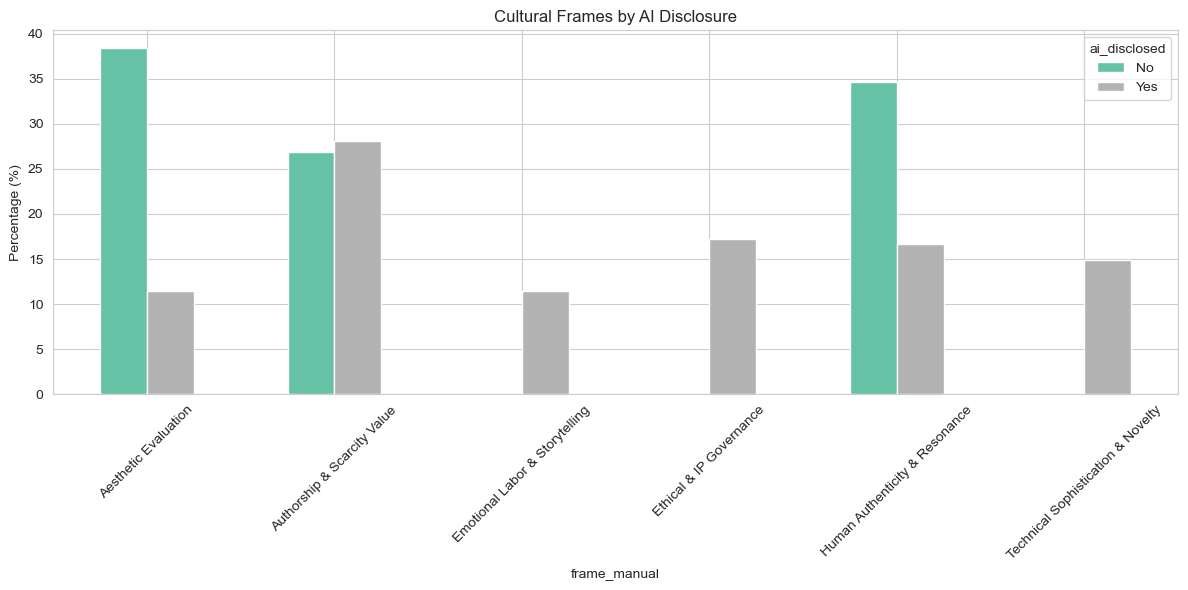

In [25]:
frame_disclosure_pivot = disclosure_frame_df.pivot(
    index="frame_manual",
    columns="ai_disclosed",
    values="percentage_within_disclosure"
)

frame_disclosure_pivot.plot(
    kind="bar",
    stacked=False,
    figsize=(12,6),
    colormap="Set2"
)

plt.ylabel("Percentage (%)")
plt.title("Cultural Frames by AI Disclosure")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Disclosure and Cultural Framing

The distribution of cultural frames differs notably between disclosed and non-disclosed AI artworks.

In the small subset of non-disclosed cases (n = 26), audience comments are concentrated in a narrower set of frames, led by **Aesthetic Evaluation**, **Human Authenticity & Resonance**, and **Authorship & Scarcity Value**.

When AI involvement is explicitly disclosed, the distribution of interpretive frames appears more diverse. In addition to authorship debates, comments also include **ethical considerations, technical novelty, aesthetic evaluation, and emotional storytelling**.

In this sample, disclosure is associated with a broader mix of interpretive frames, rather than a clear directional shift toward either positive or negative response. Because the non-disclosed group is much smaller, this pattern should be read as descriptive rather than causal.

These observations remain exploratory and should not be over-interpreted as causal effects of disclosure.

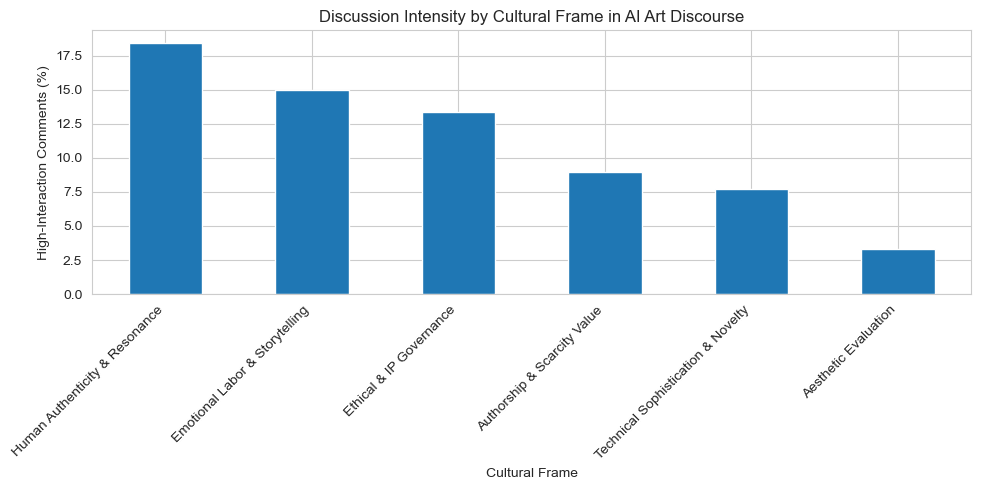

In [26]:
# ==========================================
# Discussion Intensity by Cultural Frame
# ==========================================

frame_high_rate = (
    df_discourse.groupby("frame_manual")["interaction_depth"]
    .apply(lambda x: (x == "High").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
frame_high_rate.plot(kind="bar")

plt.title("Discussion Intensity by Cultural Frame in AI Art Discourse")
plt.xlabel("Cultural Frame")
plt.ylabel("High-Interaction Comments (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretive Insight

Across the discourse analysis, technical sophistication appears to be only one part of the conversation. The more persistent interpretive tension centers on authorship, human authenticity, and whether creative value can still be attributed to labor when AI tools are involved.

## Layer 3: Market Signal Analysis

### External Market Context

After examining governance patterns and audience discourse, the final layer considers whether these cultural tensions are also reflected in observable value signals.

Using a secondary external dataset of AI-generated artworks, this section compares engagement and price patterns across creator types. The goal is not to measure intrinsic artistic value, but to assess whether AI, hybrid, and individual creators show different patterns of platform visibility and economic positioning.

Because this dataset is external and not designed around the same interpretive coding framework as the discourse sample, it should be read as contextual evidence rather than as a direct validation dataset. This layer therefore serves as a descriptive bridge between audience interpretation and market-facing signals.

In [27]:
price_col = "Price (USD)"

# ==============================
# Price sanity check
# ==============================
print(df_market[price_col].describe())
print("Missing price:", df_market[price_col].isna().sum())
print("Price <= 0:", (df_market[price_col] <= 0).sum())

# ==============================
# Create clean price dataset
# ==============================
df_market_price = df_market.copy()
df_market_price = df_market_price[df_market_price[price_col].notna()].copy()
df_market_price = df_market_price[df_market_price[price_col] > 0].copy()

print("Rows kept for price analysis:", len(df_market_price))

# ==============================
# Creator type x price summary
# ==============================
creator_price_summary = (
    df_market_price
    .groupby("Creator_Type")
    .agg(
        n=("Artwork_ID", "count"),
        mean_price=(price_col, "mean"),
        median_price=(price_col, "median"),
        std_price=(price_col, "std"),
        q1_price=(price_col, lambda x: x.quantile(0.25)),
        q3_price=(price_col, lambda x: x.quantile(0.75)),
        min_price=(price_col, "min"),
        max_price=(price_col, "max"),
    )
    .reset_index()
)

creator_price_summary["iqr_price"] = (
    creator_price_summary["q3_price"] -
    creator_price_summary["q1_price"]
)

print(creator_price_summary)

count    5000.000000
mean     2471.042898
std      1424.655213
min        13.120000
25%      1203.462500
50%      2473.475000
75%      3668.625000
max      4998.260000
Name: Price (USD), dtype: float64
Missing price: 0
Price <= 0: 0
Rows kept for price analysis: 5000
  Creator_Type     n   mean_price  median_price    std_price  q1_price  \
0     AI Model  1694  2448.083076      2436.945  1426.014567  1155.815   
1       Hybrid  1627  2497.359256      2541.910  1408.471725  1268.515   
2   Individual  1679  2468.706522      2456.240  1439.226100  1242.980   

    q3_price  min_price  max_price  iqr_price  
0  3645.3175      17.92    4997.05  2489.5025  
1  3684.3300      14.63    4998.26  2415.8150  
2  3703.4700      13.12    4992.25  2460.4900  


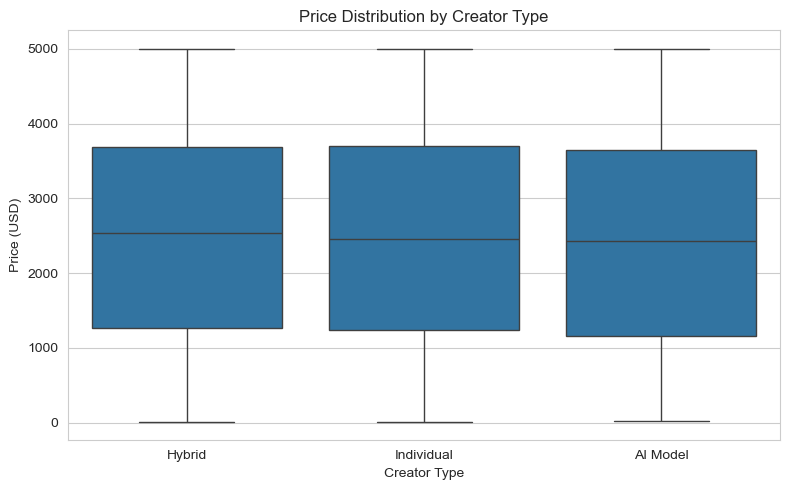

In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_market_price, x="Creator_Type", y=price_col)

plt.title("Price Distribution by Creator Type")
plt.xlabel("Creator Type")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()

#### Price Distribution Across Creator Types

The price distribution across creator types appears largely similar. 
Median prices and interquartile ranges are comparable for AI-generated, hybrid, and individual artworks, suggesting that the dataset does not show strong price differentiation based on authorship type.

This pattern indicates that market pricing alone may not strongly distinguish between AI-assisted and human-created artworks within this dataset. 
In contrast to the discourse analysis, where debates about authenticity and authorship were prominent, the observable price signals appear relatively neutral across creator categories.

### Engagement Metric Construction

Engagement rate is constructed as a normalized interaction measure:
Engagement Rate = (Likes + Comments + Shares) / Views
This metric approximates how actively audiences interact with an artwork relative to its visibility.

In [29]:
if "engagement_rate" not in df_market.columns:
    df_market["engagement_rate"] = (
        df_market["Likes"] +
        df_market["Comments"] +
        df_market["Shares"]
    ) / df_market["Views"]

# ==============================
# Clean engagement rate
# ==============================
df_market_engagement = df_market.copy()

upper = df_market_engagement["engagement_rate"].quantile(0.99)

print("Winsorization threshold (99th percentile):", upper)

df_market_engagement["engagement_rate_clean"] = df_market_engagement["engagement_rate"].clip(upper=upper)

print(df_market_engagement["engagement_rate_clean"].describe())

# ==============================
# Creator type x engagement summary
# ==============================
creator_engagement_summary = (
    df_market_engagement
    .groupby("Creator_Type")
    .agg(
        n=("Artwork_ID", "count"),
        mean_engagement=("engagement_rate_clean", "mean"),
        median_engagement=("engagement_rate_clean", "median"),
        std_engagement=("engagement_rate_clean", "std"),
        q1_engagement=("engagement_rate_clean", lambda x: x.quantile(0.25)),
        q3_engagement=("engagement_rate_clean", lambda x: x.quantile(0.75)),
        max_engagement=("engagement_rate_clean", "max")
    )
    .reset_index()
)

creator_engagement_summary["engagement_iqr"] = (
    creator_engagement_summary["q3_engagement"] -
    creator_engagement_summary["q1_engagement"]
)

print(creator_engagement_summary)

Winsorization threshold (99th percentile): 17.66167277493225
count    5000.000000
mean        0.911780
std         2.188611
min         0.008300
25%         0.208006
50%         0.331021
75%         0.656885
max        17.661673
Name: engagement_rate_clean, dtype: float64
  Creator_Type     n  mean_engagement  median_engagement  std_engagement  \
0     AI Model  1694         0.910868           0.324720        2.183666   
1       Hybrid  1627         0.932145           0.335446        2.230165   
2   Individual  1679         0.892966           0.334166        2.153802   

   q1_engagement  q3_engagement  max_engagement  engagement_iqr  
0       0.206834       0.674619       17.661673        0.467786  
1       0.208025       0.688220       17.661673        0.480195  
2       0.210843       0.615464       17.661673        0.404621  


### Engagement Patterns Across Creator Types

The engagement statistics show remarkably similar patterns across creator types.  
Mean, median, and interquartile ranges are nearly identical for AI-generated, hybrid, and individually created artworks.

The median engagement rate remains around **0.33** for all three creator categories, suggesting that typical audience interaction levels are comparable regardless of authorship type.

Although a small number of highly viral posts produce extreme engagement values, the winsorized distribution indicates that these outliers do not substantially alter the overall pattern.

Overall, the results suggest that **audience engagement does not strongly differentiate between AI-assisted and human-created artworks within this dataset**.

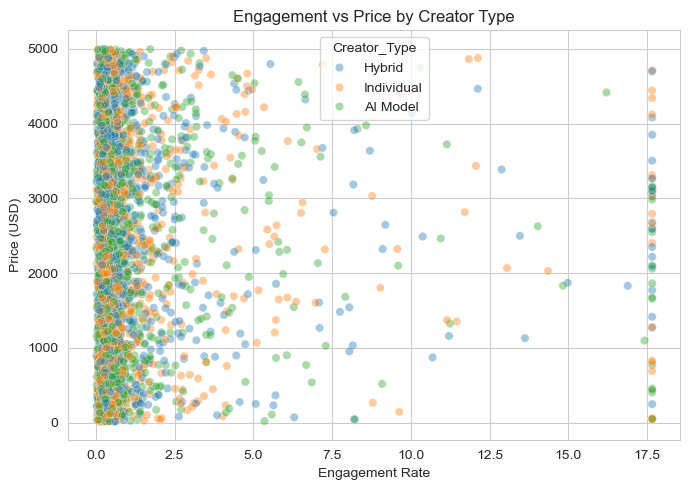

In [30]:
# ==============================
# Sanity check for Price * Engagement
# ==============================
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df_market_engagement,
    x="engagement_rate_clean",
    y="Price (USD)",
    hue="Creator_Type",
    alpha=0.4
)

plt.title("Engagement vs Price by Creator Type")
plt.xlabel("Engagement Rate")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()

In [31]:
# ==============================
# Engagement vs Price correlation
# ==============================

correlation = df_market_engagement["engagement_rate_clean"].corr(
    df_market_engagement["Price (USD)"]
)

print("Correlation between engagement and price:", round(correlation, 3))

Correlation between engagement and price: -0.008


In [32]:
# ==============================
# Engagement vs Price vs Creator Type
# ==============================

creator_value_alignment = (
    df_market_engagement
    .groupby("Creator_Type")
    .agg(
        mean_price=("Price (USD)", "mean"),
        median_price=("Price (USD)", "median"),
        mean_engagement=("engagement_rate_clean", "mean"),
        median_engagement=("engagement_rate_clean", "median")
    )
    .reset_index()
)

print(creator_value_alignment)

  Creator_Type   mean_price  median_price  mean_engagement  median_engagement
0     AI Model  2448.083076      2436.945         0.910868           0.324720
1       Hybrid  2497.359256      2541.910         0.932145           0.335446
2   Individual  2468.706522      2456.240         0.892966           0.334166


#### Engagement and Price Alignment

To examine whether audience attention translates into economic value, the correlation between engagement rate and artwork price was computed.

The correlation appears weak, suggesting that engagement signals and price signals operate largely independently in this dataset.

A further comparison across creator types also shows relatively similar patterns of both price and engagement metrics. Mean and median values remain close across AI-generated, hybrid, and individual creators.

These results indicate that while debates around authorship and authenticity are prominent in audience discourse, such tensions do not clearly translate into differentiated engagement or pricing signals at the platform level.

### When the authorship boundary between AI and human creators becomes blurred, both market pricing and audience engagement signals appear relatively undifferentiated.

## Strategic Recommendations

Based on the three-layer analysis above, I propose the following interpretive recommendations for art organizations and AI platforms. These recommendations extend beyond the dataset and should be read as strategic implications rather than direct causal findings. The governance and discourse layers provide the strongest evidentiary foundation; the market layer is more appropriately treated as external context.

### 1. Human-Centered Process Framing (High Priority)

- Insight: In this sample, frames related to emotional labor, human authenticity, and artistic process show higher shares of high-depth comments than aesthetic evaluation alone.
This suggests that audiences often engage most intensely when discussion turns to human effort, legitimacy, and creative process, rather than visual appreciation by itself.

- Action: Platforms and creators should shift communication from "AI-Generated" to "AI-Assisted Human Creativity."

- Recommended implementations:
A. Process storytelling (prompt iteration, creative decisions)

B. Creator commentary explaining artistic intent

C. Visual documentation of the human editing process

- Sustainability Impact

This strategy supports long-term cultural legitimacy by keeping AI-assisted creativity visibly connected to human intention and creative labor.

### 2. Layered Disclosure Framework

- Insight: In the current dataset, disclosed posts receive a higher share of negative comments than non-disclosed posts, but the non-disclosed group is much smaller and the notebook does not establish a causal disclosure effect.

- Action: Instead of binary disclosure (AI vs Human), platforms should introduce a multi-layered disclosure system, such as: "AI-Assisted", "Human Directed", "Hybrid Creation".

Additionally, a "Proof of Intent" badge could display:
prompt iterations
human editing stages
conceptual sketches

- Sustainability Impact

This supports more durable trust structures than simple binary labeling by emphasizing process transparency rather than only technological classification.

### 3. Creative Provenance System

- Insight: The discourse results suggest that ambiguity around creative origin is often discussed alongside distrust, authorship concerns, and value skepticism.

Artworks are not evaluated solely on visual outcome but also on their visible creative lineage.

- Action: Platforms should implement a Creative Provenance Layer that documents the creative journey, including: prompt evolution, human editing interventions, dataset disclosure (where applicable), creative timeline visualization.

Examples:
"Prompt-to-Image Evolution"
"Creative Process Timeline"

- Sustainability Impact

This encourages responsible AI art practices by shifting evaluation from AI-versus-human conflict toward accountable process transparency.

### 4. Creator Revenue Safeguards

- Insight: A recurring theme in the discourse dataset frames AI art as economic displacement of human creators, with users explicitly expressing concerns about artists losing jobs or recognition.
This indicates a legitimacy concern in public discourse, even though the external market layer does not yet show strong differentiation across creator types.

- Action: Platforms should explore creator protection mechanisms, including:

Human Creator Priority Algorithms (boost human works)

AI usage labeling tied to revenue distribution

Artist compensation pools for datasets used in AI training

Example policy models: royalty-sharing frameworks, dataset licensing agreements

- Sustainability Impact

These mechanisms are best understood as preventive governance strategies aimed at sustaining creative labor ecosystems over time.

### 5. AI Art Literacy Programs

- Insight: Many audience reactions frame AI art through moral or emotional narratives rather than technical explanation.
This may indicate a literacy gap in how AI-assisted creativity is understood and discussed, although the notebook does not directly measure audience knowledge.

- Action: Cultural institutions and platforms should develop AI literacy initiatives, such as: interactive exhibitions demonstrating AI-human collaboration, educational content explaining AI creative workflows, behind-the-scenes creator documentation.

Possible formats: museum installations, digital storytelling campaigns, creator interviews.

- Sustainability Impact

Improving audience literacy can support more informed and less reactionary cultural dialogue around AI-assisted art.

### 6. Human Craft Scarcity Positioning

- Insight: The discourse layer suggests that the value of human-made art increasingly derives from perceived rarity and authenticity in a world of scalable AI generation.
At the same time, the external market layer does not yet demonstrate a strong human-made premium in price or engagement, so this should be treated as a strategic interpretation rather than an established market fact.

- Action: Art institutions and marketplaces could develop "Human-Made Premium" positioning, including: verified human-only collections, "Human Crafted" certification labels, curated exhibitions emphasizing manual skill and lived experience.
This approach mirrors existing market dynamics in luxury goods and handcrafted industries.

- Sustainability Impact

If implemented carefully, this can preserve symbolic and cultural distinctions around human craftsmanship without overstating what the current market data proves.

#### Together, these strategies suggest that the long-term sustainability of AI-assisted art will depend less on replacing human creativity than on building governance, disclosure, and value systems that preserve human intentionality, transparency, and cultural legitimacy.